# 08 · CatBoost (supervisionado) vs Score Agregado de Células

**Objetivo:** treinar um classificador individual (CatBoost) nos mesmos microdados e
compará-lo ao score de células no MESMO holdout temporal e métricas.

**Entradas:** `data/interim/rais/ano=*/*.parquet`; tabelas de taxa (score de células).  
**Saídas:** `outputs/tables/benchmark_catboost.csv`, figuras de calibração e importância.

**Setup:** alvo binário = teve dispensa s/ justa causa no ano; features CBO, CNAE, UF,
escolaridade, tamanho (categóricas nativas do CatBoost) + idade, tempo de vínculo.
Split TEMPORAL: treino = anos anteriores, holdout = último ano.

**Premissas/Limitações:** treina em AMOSTRA (cabe em memória); horizonte = 'dentro do
ano' (não 3/6/12m); é modelo individual (contrasta com a premissa agregada do projeto).
Sem leakage: vinculo_ativo/mes_deslig/motivo/separado NÃO são features.

In [1]:
# Preâmbulo: torna o pacote src importável a partir do notebook
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT))
import pandas as pd, numpy as np
from src.config import load_config, anos_validos
cfg = load_config()
print('Raiz:', cfg['root'], '| modo sintético:', cfg['synthetic_mode'])

Raiz: /mnt/d/Projetos/Consignado | modo sintético: False


In [2]:
import time; t0=time.time()
from src import ml, scoring
MOT = cfg['motivo_default'][0]
anos = cfg['anos']; treino_anos, holdout = anos[:-1], anos[-1]
fit_anos, val_ano = treino_anos[:-1], treino_anos[-1]   # split TEMPORAL p/ early stopping
mlp = cfg['ml']
print('fit:', fit_anos, '| validação:', val_ano, '| holdout:', holdout, '| alvo:', MOT)
fit = ml.sample_microdata(fit_anos, frac=mlp['frac_treino'], seed=mlp['seed'], motivo=MOT, cfg=cfg)
val = ml.sample_microdata([val_ano], frac=mlp['frac_treino'], seed=mlp['seed'], motivo=MOT, cfg=cfg)
te  = ml.sample_microdata([holdout], frac=mlp['frac_teste'], seed=mlp['seed'], motivo=MOT, cfg=cfg)
print(f'fit={len(fit):,} val={len(val):,} holdout={len(te):,} [{time.time()-t0:.0f}s]')

fit: [2020, 2021] | validação: 2022 | holdout: 2023 | alvo: involuntario_sjc


fit=2,728,861 val=1,569,722 holdout=1,659,283 [29s]


In [3]:
# Treino do CatBoost com EARLY STOPPING na validação (2022) — holdout (2023)
# fica intocado p/ a métrica final. O nº de árvores é escolhido pela validação.
Xf, yf = ml.prepare_xy(fit)
Xv, yv = ml.prepare_xy(val)
Xte, yte = ml.prepare_xy(te)
cb = mlp['catboost']
model = ml.train_catboost(Xf, yf, Xv, yv, depth=cb['depth'],
                          learning_rate=cb['learning_rate'], iterations=cb['max_iterations'],
                          early_stopping_rounds=cb['early_stopping_rounds'], verbose=200)
p_cb = model.predict_proba(Xte)[:, 1]
print(f'CatBoost treinado | best_iteration={model.get_best_iteration()} (teto {cb["max_iterations"]}) [{time.time()-t0:.0f}s]')

0:	test: 0.6565482	best: 0.6565482 (0)	total: 628ms	remaining: 15m 41s


200:	test: 0.6925213	best: 0.6925631 (191)	total: 1m 22s	remaining: 8m 52s


Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6936975138
bestIteration = 277

Shrink model to first 278 iterations.


CatBoost treinado | best_iteration=277 (teto 1500) [175s]


In [4]:
# Score de células TREINO-ONLY (sem o holdout 2023) -> comparação JUSTA.
# As tabelas de PRODUÇÃO (data/processed/rates, todos os anos) seguem
# corretas p/ pontuar pessoas; aqui usamos uma versão out-of-time só p/
# avaliar — senão a célula 'veria' o ano de teste (vazamento).
import pandas as pd
rates_tr = ml.build_train_only_rates(cfg, holdout)   # reusa se já existir
sc_tr = scoring.Scorer(rates_dir=rates_tr, cfg=cfg)
p_cel = ml.score_celulas_array(te, sc_tr, MOT, cfg)
# referência (vazada) p/ ilustrar o efeito do leakage:
p_cel_leak = ml.score_celulas_array(te, scoring.Scorer(cfg=cfg), MOT, cfg)
bench = pd.DataFrame({'modelo': ['Células treino-only (justo)', 'CatBoost', 'Células c/ 2023 (vazado)'],
                      **{k: [ml.eval_scores(yte, p_cel)[k], ml.eval_scores(yte, p_cb)[k],
                             ml.eval_scores(yte, p_cel_leak)[k]] for k in ['AUC','Brier','LogLoss']}})
bench.to_csv(cfg['abs']['tables'] / 'benchmark_catboost.csv', index=False)
print(f'[{time.time()-t0:.0f}s]'); display(bench)

[239s]


,modelo,AUC,Brier,LogLoss
0,Células treino-only (justo),0.684880,0.110545,0.372438
1,CatBoost,0.701004,0.107731,0.360708
2,Células c/ 2023 (vazado),0.737941,0.104056,0.346371


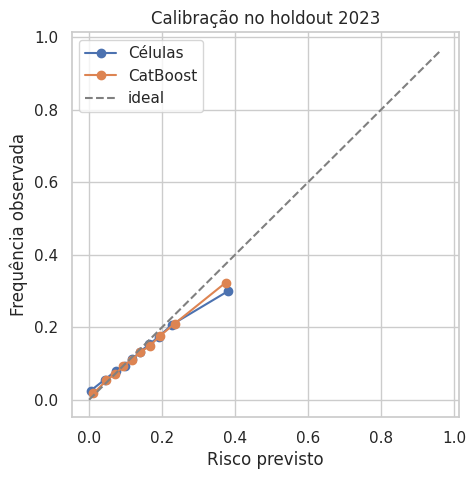

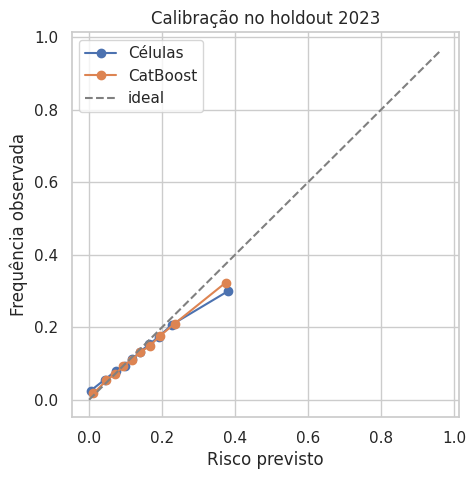

In [5]:
# Curvas de calibração (previsto vs observado por decil)
import matplotlib.pyplot as plt
from src import viz
fig, ax = plt.subplots(figsize=(5,5))
for nome, p in [('Células', p_cel), ('CatBoost', p_cb)]:
    r = ml.reliability_table(yte, p, 10)
    ax.plot(r['prevista'], r['observada'], 'o-', label=nome)
mx = max(p_cel.max(), p_cb.max())
ax.plot([0,mx],[0,mx],'--',color='gray',label='ideal')
ax.set_xlabel('Risco previsto'); ax.set_ylabel('Frequência observada')
ax.set_title(f'Calibração no holdout {holdout}'); ax.legend()
viz.save_fig(fig, cfg['abs']['figures']/'benchmark_calibracao.png'); fig

In [6]:
# Importância das variáveis no CatBoost
imp = pd.DataFrame({'feature': ml.FEATURES,
                    'importancia': model.get_feature_importance()}
                  ).sort_values('importancia', ascending=False)
imp.to_csv(cfg['abs']['tables'] / 'catboost_importancia.csv', index=False)
display(imp)

,feature,importancia
12,tempo_vinculo_meses,37.506213
10,tamanho_estab,10.794728
6,cnae3,8.701691
7,cnae2,8.621158
2,cbo2,7.257744
8,uf,6.725967
3,cbo1,5.865971
1,cbo4,3.361817
5,cnae5,3.325056
0,cbo,2.486130


## Leitura e ressalva metodológica (importante)

**Comparação justa (todos vendo só 2020-2022, testados em 2023):** o **CatBoost
supera o score de células** (ex.: AUC ~0,70 vs ~0,685). O modelo supervisionado
generaliza melhor para o ano seguinte; a taxa da célula 'envelhece' quando o ano muda.

**Cuidado com vazamento (out-of-time):** a 3ª linha do benchmark mostra as células
*com 2023 embutido* (AUC ~0,738) — número **inflado**, porque a taxa da célula já
continha os desligamentos do próprio ano de teste. Para avaliar poder preditivo é
obrigatório o holdout temporal.

**Produção ≠ avaliação:** para *pontuar uma pessoa hoje*, o score de células usa
TODOS os anos (`data/processed/rates/`) — correto, usa toda a informação. O recorte
treino-only (`rates_treino/`) existe só para esta avaliação honesta.

**Quando ainda preferir as células:** transparência total, defensabilidade (LGPD) e
operar sem treinar um modelo individual.